## Credit Scoring Model for Loan Approval Decisions

In [78]:
import pandas as pd
import numpy as np

In [79]:
columns = ['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_status', 'employment', 'installment_rate', 'personal_status',
    'other_parties', 'residence_since', 'property_magnitude', 'age',
    'other_payment_plans', 'housing', 'existing_credits', 'job',
    'num_dependents', 'own_telephone', 'foreign_worker', 'class']

df = pd.read_csv("german.data", sep=' ', header=None, names=columns)

The data we are working with is in plain text format, with values separated by spaces. It also lacks column names and a header row. Therefore, we use the sep=" " parameter for the spaces, header=None to prevent pandas from treating the first row as a header, and since there are no column titles, we define the column names based on the data before reading the file by using names=columns.

-------------------------------------------------------------------------------------------------------------------------------------
Üzərində işlədiyimiz data, sadə mətn formatındadır və dəyərlər bir-birindən boşluqla ayrılıb. Eyni zamanda, sütun adları və başlıq sütunu yoxdur. Bu zaman, boşluqlara görə, sep = " " parametri, pandasın ilk sətri başlıq hesab etməsinin qarşısını almaq üçün, header=None, sütun adları olmadığı üçün, faylı oxutmamışdan öncə məlumatlara əsaslanaraq, "column" adları təyin edirik, names=columns. 

In [80]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [81]:
df.shape

(1000, 21)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   checking_status      1000 non-null   object
 1   duration             1000 non-null   int64 
 2   credit_history       1000 non-null   object
 3   purpose              1000 non-null   object
 4   credit_amount        1000 non-null   int64 
 5   savings_status       1000 non-null   object
 6   employment           1000 non-null   object
 7   installment_rate     1000 non-null   int64 
 8   personal_status      1000 non-null   object
 9   other_parties        1000 non-null   object
 10  residence_since      1000 non-null   int64 
 11  property_magnitude   1000 non-null   object
 12  age                  1000 non-null   int64 
 13  other_payment_plans  1000 non-null   object
 14  housing              1000 non-null   object
 15  existing_credits     1000 non-null   int64 
 16  job    

In [83]:
# 1=good, 2=bad
df["class"] = df["class"].map({1: 0, 2:1})

In [84]:
df['class'].value_counts()

class
0    700
1    300
Name: count, dtype: int64

"The 'class' column was originally encoded as 1 (good) and 2 (bad). Since the model expects a standard binary format (0/1), I mapped these values to 0 (good) and 1 (bad). Specifically, 1 was assigned to 'bad' because our primary objective is to detect bad credit risk. This ensures that the model focuses on 1 as the target class.

-------------------------------------------------------------------------------------------------------------------------------------
"class" sütunu orijinalda 1 (yaxşı) və 2 (pis) kimi kodlanmışdı. Modelin standart ikili format (0/1) gözlədiyi üçün, mən bu dəyərləri 0 (yaxşı) və 1 (pis) formatına çevirdim. 1-i "pis" üçün seçdim, çünki bizim əsas məqsədimiz pis kredit riskini aşkar etməkdir. Bu, modelin hədəf sinfi kimi 1-ə fokuslanmasını təmin edir.

In [85]:
checking_status_map = {"A11": "balance < 0 DM", "A12": "0 <= balance <  200 DM",
                    "A13": "balance >= 200 DM / salary assignments for at least 1 year", 
                    "A14": "no checking account"}

In [86]:
df['checking_status'] = df['checking_status'].map(checking_status_map)
df['checking_status'].value_counts()

checking_status
no checking account                                           394
balance < 0 DM                                                274
0 <= balance <  200 DM                                        269
balance >= 200 DM / salary assignments for at least 1 year     63
Name: count, dtype: int64

In [87]:
credit_history_map = {"A30" : "no credits taken/all credits paid back duly" , 
        "A31" : "all credits at this bank paid back duly" ,
	    "A32" : "existing credits paid back duly till now" ,
        "A33" : "delay in paying off in the past" ,
	    "A34" : "critical account/other credits existing (not at this bank)"}

In [88]:
df["credit_history"] = df["credit_history"].map(credit_history_map)
df["credit_history"].value_counts()

credit_history
existing credits paid back duly till now                      530
critical account/other credits existing (not at this bank)    293
delay in paying off in the past                                88
all credits at this bank paid back duly                        49
no credits taken/all credits paid back duly                    40
Name: count, dtype: int64

In [89]:
purpose_map = {"A40" : "car (new)", "A41" : "car (used)", "A42" : "furniture/equipment", "A43" : "radio/television",
	      "A44" : "domestic appliances", "A45" : "repairs", "A46" : "education", 
	      "A47" : "(vacation - does not exist?)", "A48" : "retraining",
	      "A49" : "business", "A410" : "others"}

In [90]:
df["purpose"] = df["purpose"].map(purpose_map)
df["purpose"].value_counts()

purpose
radio/television       280
car (new)              234
furniture/equipment    181
car (used)             103
business                97
education               50
repairs                 22
domestic appliances     12
others                  12
retraining               9
Name: count, dtype: int64

In [91]:
savings_status_map ={"A61" : "... <  100 DM", "A62" : "100 <= ... <  500 DM",
	    "A63" : "500 <= ... < 1000 DM", "A64" : "... >= 1000 DM", 
        "A65" : "unknown/ no savings accoun"}

In [92]:
df["savings_status"] = df["savings_status"].map(savings_status_map)
df["savings_status"].value_counts()

savings_status
... <  100 DM                 603
unknown/ no savings accoun    183
100 <= ... <  500 DM          103
500 <= ... < 1000 DM           63
... >= 1000 DM                 48
Name: count, dtype: int64

In [93]:
employment_map = {"A71": "unemployed", "A72" : "... < 1 year",
	    "A73" : "1 <= ... < 4 years", "A74" : "4 <= ... < 7 years", "A75" :  "... >= 7 years"}

In [94]:
df["employment"] = df["employment"].map(employment_map)
df["employment"].value_counts()

employment
1 <= ... < 4 years    339
... >= 7 years        253
4 <= ... < 7 years    174
... < 1 year          172
unemployed             62
Name: count, dtype: int64

In [95]:
personal_status_map = {"A91" : "male : divorced/separated","A92" : "female : divorced/separated/married", 
      "A93" : "male : single", "A94" : "male : married/widowed", "A95" : "female : single"}

In [96]:
df["personal_status"] = df["personal_status"].map(personal_status_map)
df["personal_status"].value_counts()

personal_status
male : single                          548
female : divorced/separated/married    310
male : married/widowed                  92
male : divorced/separated               50
Name: count, dtype: int64

In [97]:
other_parties_map = {"A101" : "none", "A102" : "co-applicant", "A103" : "guarantor"}

In [98]:
df["other_parties"] = df["other_parties"].map(other_parties_map)
df["other_parties"].value_counts()

other_parties
none            907
guarantor        52
co-applicant     41
Name: count, dtype: int64

In [99]:
property_magnitude_map = {"A121" : "real estate", "A122" : "if not A121 : building society savings agreement/life insurance",
    "A123" : "if not A121/A122 : car or other, not in attribute 6", "A124" : "unknown/no property"}

In [100]:
df["property_magnitude"] = df["property_magnitude"].map(property_magnitude_map)
df["property_magnitude"].value_counts()

property_magnitude
if not A121/A122 : car or other, not in attribute 6                332
real estate                                                        282
if not A121 : building society savings agreement/life insurance    232
unknown/no property                                                154
Name: count, dtype: int64

In [101]:
other_payment_plans_map = {"A141" : "bank", "A142" : "stores", "A143" : "none"}

In [102]:
df["other_payment_plans"] = df["other_payment_plans"].map(other_payment_plans_map)
df["other_payment_plans"].value_counts()

other_payment_plans
none      814
bank      139
stores     47
Name: count, dtype: int64

In [103]:
housing_map = {"A151" : "rent", "A152" : "own", "A153" : "for free"}

In [104]:
df["housing"] = df["housing"].map(housing_map)
df["housing"].value_counts()

housing
own         713
rent        179
for free    108
Name: count, dtype: int64

In [105]:
job_map = {"A171" : "unemployed/unskilled - non-resident", "A172" : "unskilled-resident",
	    "A173" : "skilled employee/official", "A174" : "management/self-employed/highly qualified employee/officer"}

In [106]:
df["job"] = df["job"].map(job_map)
df["job"].value_counts()

job
skilled employee/official                                     630
unskilled-resident                                            200
management/self-employed/highly qualified employee/officer    148
unemployed/unskilled - non-resident                            22
Name: count, dtype: int64

In [107]:
own_telephone_map = {"A191" : "none", "A192" : "yes, registered under the customers name"}

In [108]:
df["own_telephone"] = df["own_telephone"].map(own_telephone_map)
df["own_telephone"].value_counts()

own_telephone
none                                        596
yes, registered under the customers name    404
Name: count, dtype: int64

In [109]:
foreign_worker_map = {"A201" : "yes", "A202" : "no"}

In [110]:
df["foreign_worker"] = df["foreign_worker"].map(foreign_worker_map)
df["foreign_worker"].value_counts()

foreign_worker
yes    963
no      37
Name: count, dtype: int64

To ensure the readability of the model's and SHAP's final outputs, I mapped all existing 'object' type attributes in the file using a dictionary. Additionally, I verified with 'value_counts()' that the conversion was executed correctly and without any data loss.

-------------------------------------------------------------------------------------------------------------------------------------
Faylda mövcud olan bütün "object" tipli atributeləri, modelin və SHAP-ın son nəticəsini oxunaqlı etmək üçün, "dictionary" ilə çevirmə etdim. "value_counts()"la da, çevirmənin düzgün, itkisiz aparıldığını yoxladım.

In [111]:
df.isnull().sum()

checking_status        0
duration               0
credit_history         0
purpose                0
credit_amount          0
savings_status         0
employment             0
installment_rate       0
personal_status        0
other_parties          0
residence_since        0
property_magnitude     0
age                    0
other_payment_plans    0
housing                0
existing_credits       0
job                    0
num_dependents         0
own_telephone          0
foreign_worker         0
class                  0
dtype: int64

## One-Hot Encoding

In [112]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [113]:
df_encoded.head()

,duration,credit_amount,installment_rate,residence_since,age,existing_credits,num_dependents,class,checking_status_balance < 0 DM,checking_status_balance >= 200 DM / salary assignments for at least 1 year,...,property_magnitude_unknown/no property,other_payment_plans_none,other_payment_plans_stores,housing_own,housing_rent,job_skilled employee/official,job_unemployed/unskilled - non-resident,job_unskilled-resident,"own_telephone_yes, registered under the customers name",foreign_worker_yes
0,6,1169,4,4,67,2,1,0,True,False,...,False,True,False,True,False,True,False,False,True,True
1,48,5951,2,2,22,1,1,1,False,False,...,False,True,False,True,False,True,False,False,False,True
2,12,2096,2,3,49,1,2,0,False,False,...,False,True,False,True,False,False,False,True,False,True
3,42,7882,2,4,45,1,2,0,True,False,...,False,True,False,False,False,True,False,False,False,True
4,24,4870,3,4,53,2,2,1,True,False,...,True,True,False,False,False,True,False,False,False,True


In [114]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 49 columns):
 #   Column                                                                      Non-Null Count  Dtype
---  ------                                                                      --------------  -----
 0   duration                                                                    1000 non-null   int64
 1   credit_amount                                                               1000 non-null   int64
 2   installment_rate                                                            1000 non-null   int64
 3   residence_since                                                             1000 non-null   int64
 4   age                                                                         1000 non-null   int64
 5   existing_credits                                                            1000 non-null   int64
 6   num_dependents                                                   

Although I previously mapped the categorical columns into human-readable text using a dictionary, the machine learning model cannot process text directly and requires numerical inputs. Therefore, I applied the pd.get_dummies() function to convert each categorical variable into a binary 0/1 (True/False) format.

This process expanded each category into separate columns (e.g., the checking_status column was transformed from 4 categories into 3 new columns). By setting the drop_first=True parameter, I excluded the reference category from each group to prevent multicollinearity. Consequently, when all remaining dummy columns for a feature are 0, it automatically represents the omitted baseline category.

As a result of this encoding, the total number of columns increased from 21 to 49. The existing numerical features (such as duration, age, and credit_amount) remained unchanged.

-------------------------------------------------------------------------------------------------------------------------------------
Kateqorik sütunları, əvvəlcə dictionary ilə oxunaqlı mətnə çevirmişdim, amma model bu mətnlə birbaşa işləyə bilmir, yalnız rəqəmlərlə işləyir. Ona görə "pd.get_dummies()" funksiyası ilə hər kateqorik sütunu 0/1 (True/False) formatına çevirdim.

Bu proses hər kateqoriyanı ayrı bir sütuna böldü (məsələn checking_status sütunu 4 kateqoriyadan 3 yeni sütuna bölündü). "drop_first=True" parametri ilə hər sütun qrupundan birini (əsas/reference kateqoriya) çıxardım ki, sütunlar arasında lazımsız təkrar məlumat (multicollinearity) yaranmasın. Qalan sütunların hamısı 0 olanda, bu, avtomatik çıxarılan kateqoriyanı bildirir.

Bu addımdan sonra sütun sayı 21-dən 49-a çatdı, çünki hər kateqoriya öz sütunlarına bölündü. Rəqəm sütunlara (duration, age,credit_amount vəs.) toxunulmadı, onlar olduğu kimi qaldı.

## Feature-Target Split

In [115]:
X = df_encoded.drop("class", axis=1)
y = df_encoded["class"]

In [116]:
X.shape

(1000, 48)

In [117]:
y.shape

(1000,)

In [118]:
import re

In [119]:
X.columns = [col.replace("<", "under").replace(">=", "over").replace("=", "")
    .replace(" ", "_").replace("__", "_") for col in X.columns]
X.shape, y.shape

((1000, 48), (1000,))

I removed/replaced special characters such as <, >=, and = from the column names because XGBoost does not support them and threw an error. Instead of simply deleting them, I replaced them with meaningful words (< → "under", >= → "over") to keep the column names both XGBoost-compatible and readable. I then replaced remaining spaces with underscores (_) and cleaned up double underscores.

-------------------------------------------------------------------------------------------------------------------------------------
Sütun adlarındakı <, >=, = kimi simvolları təmizlədim, çünki XGBoost bu simvolları qəbul etmir və xəta verirdi. Sadəcə silmək əvəzinə, onları mənalı sözlərlə əvəz etdim (< → "under", >= → "over") ki, sütun adları həm XGBoost-a uyğun olsun, həm də oxunaqlılığını itirməsin. Sonra qalan boşluqları alt xətt (_) ilə əvəz etdim və təkrarlanan alt xətləri təmizlədim.

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape

((800, 48), (200, 48))

## Baseline model (Logistic Regression)

In [122]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [123]:
log_model = LogisticRegression(max_iter=5000, class_weight="balanced")
log_model.fit(X_train, y_train)

c:\Users\NP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [124]:
y_pred_log = log_model.predict(X_test)
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80       140
           1       0.56      0.82      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.77      0.73       200
weighted avg       0.80      0.75      0.76       200



[[101  39]
 [ 11  49]]


In the initial logistic regression model, I encountered a ConvergenceWarning because the default max_iter=1000 was insufficient for convergence. I resolved this issue by increasing max_iter to 5000. Consequently, the recall for class 1 improved from 0.80 to 0.82, and the number of False Negatives (FN) decreased from 12 to 11. Based on the cost matrix, the total financial cost was reduced from 95 to 94.

-------------------------------------------------------------------------------------------------------------------------------------
İlkin logistic regression modelində ConvergenceWarning xətası aldım (max_iter=1000 kifayət etmirdi). max_iter=5000 edərək bunu düzəltdim. Nəticədə recall (sinif 1) 0.80-dən 0.82-yə yüksəldi, FN sayı 12-dən 11-ə düşdü. Xərc matrisinə görə cəmi xərc 95-dən 94-ə azaldı.

## XGBoost model

In [125]:
from xgboost import XGBClassifier

In [126]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(scale_pos_weight = scale, eval_metric="logloss", random_state=42)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.81      0.82      0.82       140
           1       0.57      0.55      0.56        60

    accuracy                           0.74       200
   macro avg       0.69      0.69      0.69       200
weighted avg       0.74      0.74      0.74       200

[[115  25]
 [ 27  33]]


Logistic Regression-dan sonra, tapşırığın tələbinə uyğun olaraq XGBoost modelini də qurdum ki, iki alqoritmi müqayisə edim. XGBoost-u seçdim, çünki o, cədvəl (tabular) data üzərində güclü performans göstərir və xüsusiyyətlər arasındakı mürəkkəb, qeyri-xətti əlaqələri (Logistic Regression-un tuta bilmədiyi) öyrənə bilir.

Balanssızlığı idarə etmək üçün "scale_pos_weight" parametrini istifadə etdim (Logistic Regression-dakı class_weight="balanced"-in ekvivalenti kimi), scale = (y_train == 0).sum() / (y_train == 1).sum().

Nəticə (default 0.5 həddi ilə):
- Recall (sinif 1, pis müştəri): 0.55
- Precision (sinif 1): 0.57
- Xərc (5×FN + 1×FP): 160

Bu nəticə Logistic Regression-dan (recall=0.82, xərc=94) PİS çıxdı.Çünki, "scale_pos_weight" modelin təlim prosesini balanslaşdırsa da, ".predict()" metodu hələ də default 0.5 həddini istifadə edir. Bu, bizim xərc matrisimizə uyğun deyil. Növbəti addımda "predict_proba()" ilə optimal hədd tapıb, XGBoost-un əsl potensialını qiymətləndirəcəm.

## Threshold setting

In [127]:
y_proba = xgb_model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.01, 0.9, 0.01)
best_threshold = None
best_cost = float('inf')

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    cost = 5*fn+1*fp 
    if cost < best_cost:
        best_cost = cost
        best_threshold = t
print("Best Limit:", best_threshold, "Lowest Cost:", best_cost)

Best Limit: 0.06999999999999999 Lowest Cost: 103


In the model, xgb_model.predict() automatically uses a 0.5 threshold. In other words, "if the probability is over 50%, classify as bad." However, our cost matrix is at a 5:1 ratio, and we must strive to identify "bad" customers with high accuracy.

.predict_proba() returns the probabilities for both classes. Since we only need the probability of being "bad", we extract only the class 1 probabilities using [:, 1]. y_proba is the array storing the generated probabilities for each customer. Since we do not know in advance which threshold is best, we define a range of multiple thresholds.

Initially, I set the step size between probabilities to 0.05, which yielded a "best threshold" of 0.1 (with a lowest cost of 118). Finding the best result at the edge, or boundary, of the tested range creates a "boundary issue." This means we are observing the data through too narrow of a lens.

To test this suspicion, I first reduced the step size to 0.01 but kept the starting point of the range at 0.1. The result was a best_threshold of 0.11 and a cost of 115. This was slightly better than the previous result (cost = 118), but since 0.11 was still close to the 0.1 boundary, it did not fully resolve my suspicion.

Next, I restarted the range from the absolute minimum (0.01) and tested again using thresholds = np.arange(0.01, 0.9, 0.01). This time, the result changed completely, yielding a best_threshold of approximately 0.07 and a cost of 103. This confirmed that my boundary suspicion was correct. The true optimal threshold was below 0.1, which I had missed in the initial tests. Consequently, the final optimal threshold for XGBoost is 0.07, resulting in a cost (\(5 \times \text{FN} + 1 \times \text{FP}\)) of 103. 

-------------------------------------------------------------------------------------------------------------------------------------
Modeldə, "xgb_model.predict()" avtomatik olaraq 0.5 həddini istifadə edir. Yəni "əgər ehtimal 50%-dən çoxdursa, pis de". Lakin, bizim xərc matrisimiz 5:1 nisbətindədir və " pis" müştəriləri dəqiqliklə təyin etməyə çalışmalıyıq.

".predict_proba()" bizə hər iki sinif üçün ehtimalları qaytarır. bizə isə sadəcə "pis" olma ehtimalı lazım oldduğuna görə, [: , 1] ilə sadəcə sinif 1-in ehtimalını götürürük. "y_proba" müştərilərin hər biri üçün  çıxan ehtimalları saxlayan siyahıdır. Hansı həddin yaxşı olduğunu əvvəlcədən bilmirik deyə, bir neçə hədd təyin edirik.

İlk öncə ehtimallar arasındakı addımı 0.05 təyin etmişdim bu halda "best limit" 0.1 çıxırdı (lowest cost isə118). Tapılan ən yaxşı nəticənin, sınadığım aralığın kənarında, yəni sərhəddində çıxması "sərhəd problemi" yardır. Yəni dar baxış bucağı ilə müşahidə aprırmış oluruq.

Bu şübhəni yoxlamaq üçün, əvvəlcə addımı kiçiltdim (0.01), amma aralığı hələ 0.1-dən başlatdım. Nəticə, best_threshold=0.11, 
cost=115. Bu, əvvəlkindən (cost=118) bir az yaxşı idi, amma 0.11 rəqəmi hələ də 0.1 sərhədinə yaxın olduğu üçün, şübhəmi tam aradan qaldırmadı.

Sonra aralığı əsl minimumdan (0.01) başladıb yenidən yoxladım, thresholds = np.arange(0.01, 0.9, 0.01). Bu dəfə nəticə tamamilə dəyişdi, best_threshold≈0.07, cost=103. Bu, sərhəd şübhəmin doğru olduğunu təsdiqlədi. Əsl optimal hədd 0.1-dən aşağıda imiş, mən onu ilk sınaqlarda gözdən qaçırmışdım. Nəticə olaraq, XGBoost üçün son optimal hədd 0.07-dir, bu həddə xərc (5×FN+1×FP) = 103-dür.

In [128]:
y_proba_log = log_model.predict_proba(X_test)[:,1]

thresholds = np.arange(0.01, 0.9, 0.01)
best_threshold = None
best_cost = float('inf')

for t in thresholds:
    y_pred_t = (y_proba_log >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    cost = 5*fn+1*fp 
    if cost < best_cost:
        best_cost = cost
        best_threshold = t
print("Best Limit:", best_threshold, "Lowest Cost:", best_cost)

Best Limit: 0.46 Lowest Cost: 90


To ensure a fairer comparison between the models, I decided to tune the threshold for the Logistic Regression model as well. Here, I proceeded with the same range (thresholds = np.arange(0.01, 0.9, 0.01)).

-------------------------------------------------------------------------------------------------------------------------------------
Modellər arasında müqayisənin daha ədalətli olması üçün, Logistic Regression modelinədə threshold təyin etmək qərarına gəldim. Burada da, eyni sərhədlə davam etdim (thresholds = np.arange(0.01, 0.9, 0.01)). 

## Final model comparison

1. Model: Logistic Regression | Optimal threshold: 0.46 | Cost: 90

2. Model: XGBoost | Optimal threshold: 0.07 | Cost: 103

Logistic Regression yielded a lower cost than XGBoost. Interestingly, the optimal threshold for LR (0.46) is close to the default 0.5, whereas for XGBoost (0.07), it is very far from the default.

As a result, I selected Logistic Regression (threshold=0.46) as the final model.

-------------------------------------------------------------------------------------------------------------------------------------
1. Model: Logistic Regression | Optimal threshold: 0.46 | Xərc: 90

2. Model: XGBoost | Optimal threshold: 0.07 | Xərc: 103

Logistic Regression, XGBoost-dan daha aşağı xərc verdi. Maraqlıdır ki, LR-in optimal həddi (0.46) default 0.5-ə yaxındır, XGBoost-un isə (0.07) default-dan çox uzaqdır.

Nəticədə, final model olaraq Logistic Regression-u (threshold=0.46) seçdim.

## SHAP

In [129]:
import shap

In [130]:
# Data tiplərini vahidləşdirmək (bool/int qarışıqlığını aradan qaldırmaq)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

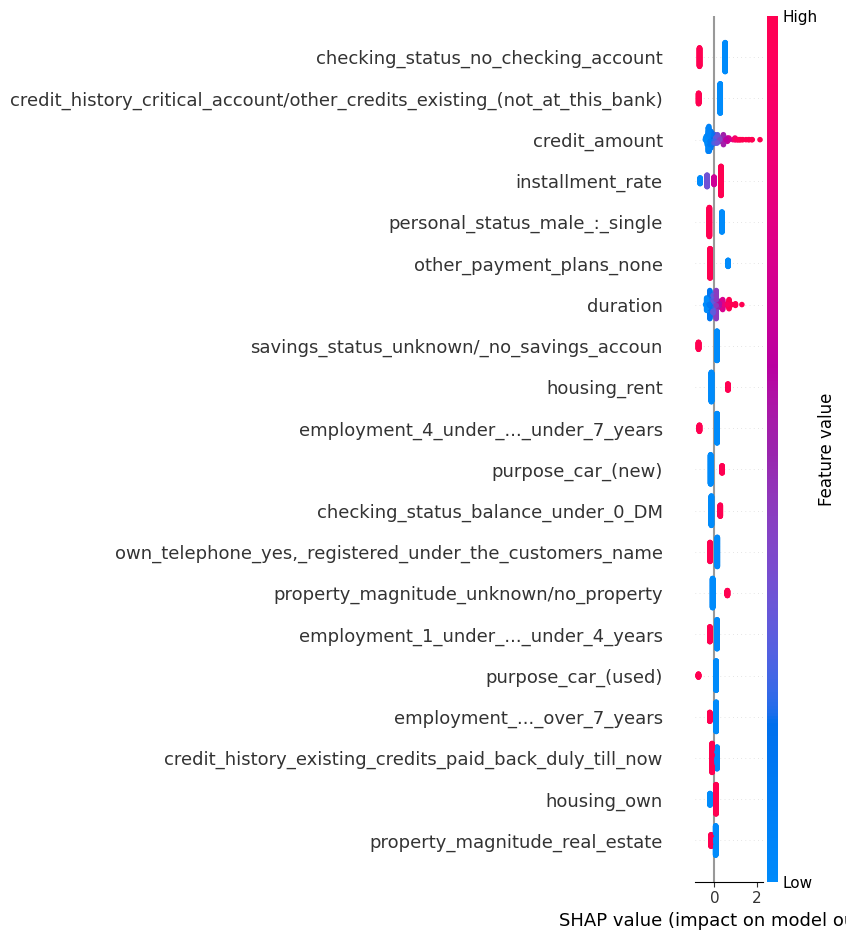

In [131]:
explainer = shap.LinearExplainer(log_model, X_train)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [132]:
mean_shap = pd.DataFrame({"feature": X_test.columns, "mean_shap_value": shap_values.mean(axis=0)}
    ).sort_values('mean_shap_value', key=abs, ascending=False)

print(mean_shap.head(10))

                                      feature  mean_shap_value
14                          purpose_car_(new)        -0.069859
39                   other_payment_plans_none        -0.054767
26  savings_status_unknown/_no_savings_accoun        -0.047529
1                               credit_amount         0.045300
9         checking_status_no_checking_account         0.036011
7          checking_status_balance_under_0_DM        -0.027098
0                                    duration         0.022117
47                         foreign_worker_yes         0.020881
38     property_magnitude_unknown/no_property         0.020744
29       employment_4_under_..._under_7_years        -0.020622


According to the SHAP analysis, "credit_amount" and "duration" clearly emerged among the most influential features. High credit amounts and longer durations cause the model to assess a higher risk. This aligns perfectly with real-world credit practices. I also confirmed the exact direction of influence for categorical features (checking_status, credit_history) by calculating their mean SHAP values.

-------------------------------------------------------------------------------------------------------------------------------------
SHAP təhlilinə görə, ən təsirli amillər arasında "credit_amount" və duration aydın şəkildə göründü. Yüksək kredit məbləği və uzun müddət, modelin riski daha yüksək qiymətləndirməsinə səbəb olur. Bu, real kredit təcrübəsi ilə üst-üstə düşür. Kateqorik xüsusiyyətlərin (checking_status, credit_history) dəqiq təsir istiqamətini isə orta SHAP dəyərləri hesablayaraq təsdiqlədim.